# IMDb NLP Processor - Actividad Práctica

## Unidad 2 - Clase 1: Text Mining y Embeddings Contextuales

Esta actividad trabaja el flujo completo de procesamiento de texto sobre el dataset IMDb de Kaggle, sin usar Transformers ni modelos preentrenados.

## Objetivos de aprendizaje
- Leer y explorar un dataset real de reseñas.
- Limpiar texto de forma sistemática.
- Tokenizar y convertir a secuencias numéricas.
- Aplicar padding (pre/post) y justificar la elección.
- Visualizar una Embedding Layer y entender su salida.

In [44]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Resolve paths relative to this notebook's location
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
file_path = PROJECT_ROOT / "dataset" / "imdb_reviews.csv"

src_path = str(PROJECT_ROOT / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from preprocessing import clean_dataframe, show_before_after
from tokenizer_utils import build_tokenizer, texts_to_sequences, top_n_words, apply_padding


In [45]:
# --- BLOQUE OPCIONAL: ACTIVAR/CONFIGURAR GPU ---
# Si ya tienes tu entorno configurado, puedes dejarlo en False.
USE_GPU = True  # Cambia a False si no quieres usar GPU

if USE_GPU:
    import tensorflow as tf
    
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        # Evita que TensorFlow reserve toda la memoria de la GPU al inicio.
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU detectada(s): {len(gpus)}")
        for i, gpu in enumerate(gpus):
            print(f"  GPU {i}: {gpu.name}")
    else:
        print("No se detectó GPU. Se usará CPU.")
else:
    print("Bloque GPU opcional desactivado (USE_GPU=False).")

GPU detectada(s): 1
  GPU 0: /physical_device:GPU:0


## Carga del dataset
El CSV esperado es `dataset/imdb_reviews.csv` con columnas `review` y `sentiment`.

Si aún no tienes el archivo real de Kaggle, el notebook creará una muestra mínima de demostración para no bloquear el flujo, pero debes reemplazarla para la entrega final.

In [46]:
df = pd.read_csv(file_path)



## Muestreo opcional para acelerar práctica
Puedes elegir entre usar todo el dataset o tomar una muestra (por ejemplo, 2,000 a 5,000 registros).

In [47]:
print("cantidad de registros: ", len(df))
df.head()


cantidad de registros:  50000


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


# Parte 1 - Exploración del Dataset (EDA)

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [49]:
def add_review_length(df):
    out = df.copy()
    out['review_length'] = out['review'].apply(len)
    out['review_length'] = out['review_length'].astype(int)
    return out

def sentiment_distribution(df):
    return df['sentiment'].value_counts(dropna=False)

def_eda = add_review_length(df)

print("cantidad de registros: ", len(def_eda))
print("cantidad de registros por clase:")
print(sentiment_distribution(def_eda))



cantidad de registros:  50000
cantidad de registros por clase:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


**Interpretación sugerida:**
- Verifica si las clases están balanceadas o no.
- Evalúa si hay reseñas extremadamente largas/cortas que puedan afectar el padding.
- Identifica si conviene truncar secuencias en un percentil de longitud.

# Parte 2 - Limpieza del Texto

In [50]:
df_clear = clean_dataframe(df, text_col='review')

display(df_clear.head())

,review,sentiment,review_clean
0,One of the other reviewers has mentioned that ...,positive,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,positive,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,positive,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,negative,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,petter mattei s love in the time of money is a...


**¿Por qué estas transformaciones?**
- Minúsculas: reduce variación artificial (`Great` vs `great`).
- HTML/URLs: suelen ser ruido para sentimiento en este nivel.
- Números y signos: simplifican vocabulario inicial.
- Espacios repetidos: normaliza y evita tokens vacíos.

# Parte 3 - Tokenización

In [51]:
NUM_WORDS = 30000

tokenizer = build_tokenizer(df_clear['review_clean'], num_words=NUM_WORDS, oov_token="<OOV>")
sequences = texts_to_sequences(tokenizer, df_clear['review_clean'])

print(f"Cantidad de secuencias generadas: {len(sequences)}")
print(f"Top 20 de palabras más frecuentes")
for word, index in top_n_words(tokenizer, n=20):
    print(f"{word} -> {index}")

Cantidad de secuencias generadas: 50000
Top 20 de palabras más frecuentes
the -> 668005
and -> 324439
a -> 323057
of -> 289413
to -> 268123
is -> 211091
it -> 190862
in -> 186785
i -> 175626
this -> 151001
that -> 143880
s -> 129787
was -> 95606
as -> 91764
movie -> 87971
for -> 87471
with -> 87368
but -> 83553
film -> 79705
you -> 69131


**Explicación técnica:** cada reseña se convierte en una lista de enteros según `word_index`. Ese diccionario asigna un índice único a cada palabra del vocabulario.

# Parte 4 - Padding

In [52]:
MAX_LEN = 200

pad_pre = apply_padding(sequences, max_len=MAX_LEN, padding='pre')
pad_post = apply_padding(sequences, max_len=MAX_LEN, padding='post')

print(f"Forma de las secuencias con padding 'pre': {pad_pre.shape}")
print(f"Forma de las secuencias con padding 'post': {pad_post.shape}")

Forma de las secuencias con padding 'pre': (50000, 200)
Forma de las secuencias con padding 'post': (50000, 200)


**Estrategia seleccionada:** `post-padding`.

Justificación: en reseñas suele ser útil mantener el inicio del texto (contexto inicial), y agregar ceros al final facilita inspección y comparación de ejemplos en esta etapa formativa.

# Parte 5 - Introducción a Word Embeddings

In [53]:

vocab_size = len(tokenizer.word_index) + 1  # +1 para incluir el token de padding
print(f"Tamaño del vocabulario (limitado): {vocab_size}")

EMBEDDING_DIM = 32

model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(8, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Tamaño del vocabulario (limitado): 99295
Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_6 (Embedding)     (None, 200, 32)           3177440   
                                                                 
 global_average_pooling1d_6   (None, 32)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_18 (Dense)            (None, 16)                528       
                                                                 
 dense_19 (Dense)            (None, 8)                 136       
                                                                 
 dense_20 (Dense)            (None, 1)                 9         
                                                                 
Total params: 3,178,113
Trainable params: 3,178,113
Non-trainable params: 0
___

In [54]:
x = pad_post
y = df_clear['sentiment'].apply(lambda x: 1 if x == 'positive' else 0).values # convertir a 1 para positivo y 0 para negativo

**Explicación de capas:**
- `Embedding`: convierte IDs de palabras a vectores densos.
- `GlobalAveragePooling1D`: resume la secuencia en un único vector promedio.
- `Dense`: proyección lineal/no lineal mínima para obtener una salida escalar.

# Parte 6 - Reflexión Técnica

Responde con argumentos técnicos:

1. ¿Por qué un modelo de IA no puede trabajar directamente con texto?
2. ¿Cuál es la función del Tokenizer?
3. ¿Qué representa el `word_index`?
4. ¿Por qué todas las secuencias deben tener la misma longitud?
5. ¿Qué ventaja ofrece una Embedding Layer frente a usar solo números enteros?
6. ¿Qué dificultades encontraste durante el procesamiento del dataset?

# Entrenamiento completo del modelo (enfoque de aprendizaje)
En esta sección entrenaremos un modelo más sólido para práctica real, evaluaremos su desempeño y haremos inferencia con textos escritos por el usuario.

In [55]:

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.utils.class_weight import compute_class_weight

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

classes = np.unique(y_train)
class_weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

EPOCHS = 30
BATCH_SIZE = 512
LEARNING_RATE = 1e-3



### Bloque 2: definición y compilación del modelo
Se define una arquitectura más robusta y luego se compila con métricas útiles para seguimiento del aprendizaje.

In [56]:
model = tf.keras.Sequential([
    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=EMBEDDING_DIM, input_length=MAX_LEN),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(1, activation='sigmoid'),
])

model.compile(loss='binary_crossentropy', optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE), metrics=['accuracy'])

model.summary()

Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_7 (Embedding)     (None, 200, 32)           3177440   
                                                                 
 global_average_pooling1d_7   (None, 32)               0         
 (GlobalAveragePooling1D)                                        
                                                                 
 dense_21 (Dense)            (None, 128)               4224      
                                                                 
 dropout_6 (Dropout)         (None, 128)               0         
                                                                 
 dense_22 (Dense)            (None, 64)                8256      
                                                                 
 dropout_7 (Dropout)         (None, 64)                0         
                                                      

### Bloque 3: callbacks y entrenamiento
Entrenamos por más épocas con EarlyStopping y ReduceLROnPlateau para mejorar estabilidad.

In [57]:
#aplicar early stopping para evitar overfitting

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train, 
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE, 
    validation_split=0.2, 
    class_weight=class_weight_dict, 
    callbacks=[early_stopping]
    )

Epoch 1/30
63/63 [==============================] - 2s 15ms/step - loss: 0.6650 - accuracy: 0.6482 - val_loss: 0.5553 - val_accuracy: 0.7711
Epoch 2/30
63/63 [==============================] - 1s 11ms/step - loss: 0.3886 - accuracy: 0.8434 - val_loss: 0.3177 - val_accuracy: 0.8656
Epoch 3/30
63/63 [==============================] - 1s 12ms/step - loss: 0.2395 - accuracy: 0.9085 - val_loss: 0.2971 - val_accuracy: 0.8770
Epoch 4/30
63/63 [==============================] - 1s 11ms/step - loss: 0.1771 - accuracy: 0.9382 - val_loss: 0.3093 - val_accuracy: 0.8764
Epoch 5/30
63/63 [==============================] - 1s 12ms/step - loss: 0.1316 - accuracy: 0.9572 - val_loss: 0.3399 - val_accuracy: 0.8740
Epoch 6/30
63/63 [==============================] - 1s 12ms/step - loss: 0.0988 - accuracy: 0.9710 - val_loss: 0.3957 - val_accuracy: 0.8679


### Bloque 4: métricas y curvas de entrenamiento
Evaluamos métricas principales y visualizamos las curvas para analizar el comportamiento del modelo por época.

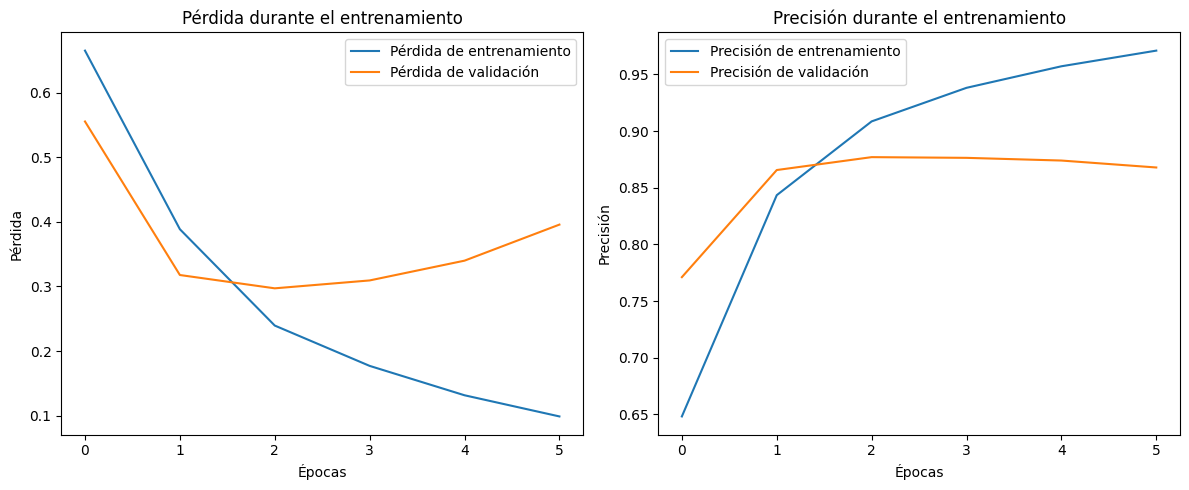

In [58]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Pérdida de entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Precisión de entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión de validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

### Bloque 5: matriz de confusión y reporte de clasificación
Se evalúa la calidad del modelo con métricas por clase y una matriz de confusión.

313/313 [==============================] - 1s 2ms/step
              precision    recall  f1-score   support

    Negativo       0.87      0.89      0.88      4961
    Positivo       0.89      0.87      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



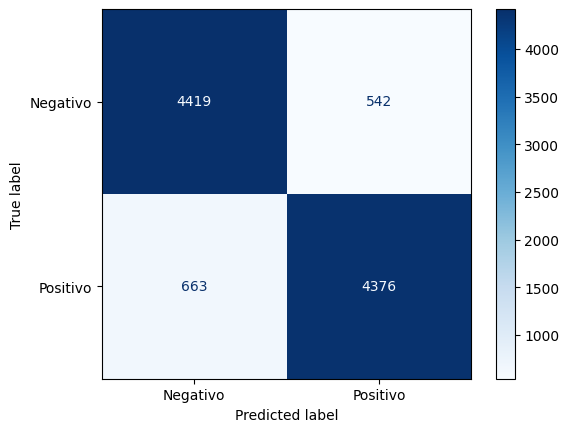

In [62]:
y_prob = model.predict(X_test, verbose=1).ravel()  # Aplanar el array de predicciones
y_pred = (y_prob >= 0.5).astype(int)  # Convertir probabilidades a etiquetas binarias

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negativo', 'Positivo'])
disp.plot(cmap='Blues')

print(classification_report(y_test, y_pred, target_names=['Negativo', 'Positivo']))

### Bloque 6: función de inferencia y ejemplos
Creamos una función reutilizable para predecir sentimiento sobre cualquier texto nuevo.

### Bloque 7: predicción manual con texto del usuario
Puedes escribir tu propia reseña en inglés para obtener una predicción del modelo entrenado.

In [69]:
texto = "Finally something new and fresh from the stereotypical drivel being jammed down our throats for the past couple of years. None of the clichés either. Dark,gory hilarious, ethically mind bending. Like how far would you twist justice to serve your needs, what price would you be willing to pay for revenge is it worth losing your humanity? All this mixed into a beautiful first season. Can't wait for more. A definite must watch epically if you enjoyed titles like Titans."

def predict_sentiment(text, tokenizer, model, max_len=MAX_LEN):
    # Limpiar el texto
    text_clean = clean_dataframe(pd.DataFrame({'review': [text]}), text_col='review')['review_clean'].iloc[0]
    
    # Convertir a secuencia
    sequence = texts_to_sequences(tokenizer, [text_clean])
    
    # Aplicar padding
    padded_sequence = apply_padding(sequence, max_len=max_len, padding='post')
    
    # Predecir
    prob = model.predict(padded_sequence, verbose=0).ravel()[0]
    sentiment = 'Positivo' if prob >= 0.5 else 'Negativo'
    
    return sentiment, prob

sentiment, probability = predict_sentiment(texto, tokenizer, model)
print(f"Sentimiento predicho: {sentiment} (Probabilidad: {probability:.4f})")

Sentimiento predicho: Positivo (Probabilidad: 0.7519)


## Cierre pedagógico
Este repositorio queda listo para extenderse durante la Unidad 2 con embeddings avanzados, Transformers, BERT y fine-tuning en próximas clases.